In [8]:
# ============================================
# Healthcare Dataset - Advanced Analytics.ipynb
# ============================================


# --- 1. Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report

✅ Dataset Loaded Successfully!

--- Shape of Dataset ---
(55500, 15)

--- Column Names ---
['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']

--- Data Types ---
Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object

--- First 5 Rows ---


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal



--- Missing Values ---
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

--- Duplicate Rows Found: 534 ---

--- Summary Statistics ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Name,55500,49992,DAvId muNoZ,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,55500.0,NaN,NaN,NaN,51.539459,19.602454,13.0,35.0,52.0,68.0,89.0
Gender,55500,2,Male,27774,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Blood Type,55500,8,A-,6969,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medical Condition,55500,6,Arthritis,9308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date of Admission,55500,1827,2024-03-16,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Doctor,55500,40341,Michael Smith,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hospital,55500,39876,LLC Smith,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Insurance Provider,55500,5,Cigna,11249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Billing Amount,55500.0,NaN,NaN,NaN,25539.316097,14211.454431,-2008.49214,13241.224652,25538.069376,37820.508436,52764.276736



Numeric Columns: ['Age', 'Billing Amount', 'Room Number']
Categorical Columns: ['Name', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']

--- Numeric Column Distributions ---


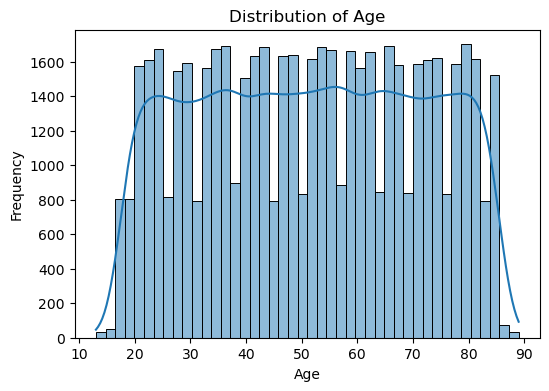

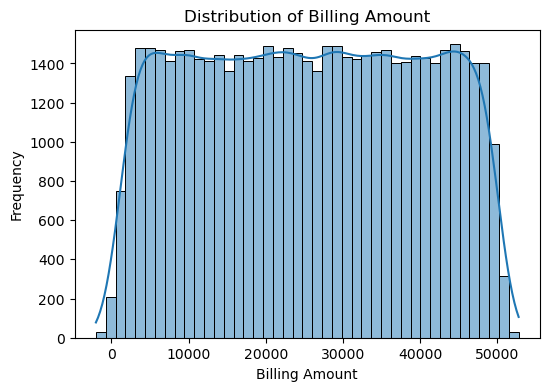

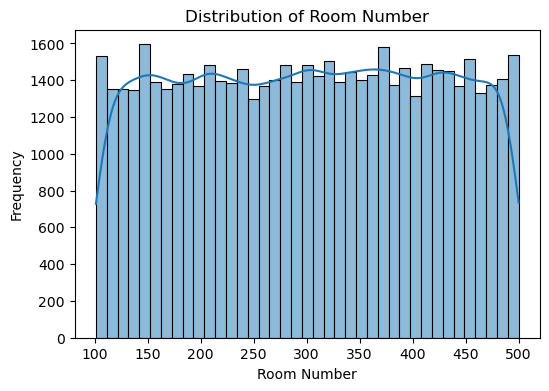


--- Categorical Column Counts ---


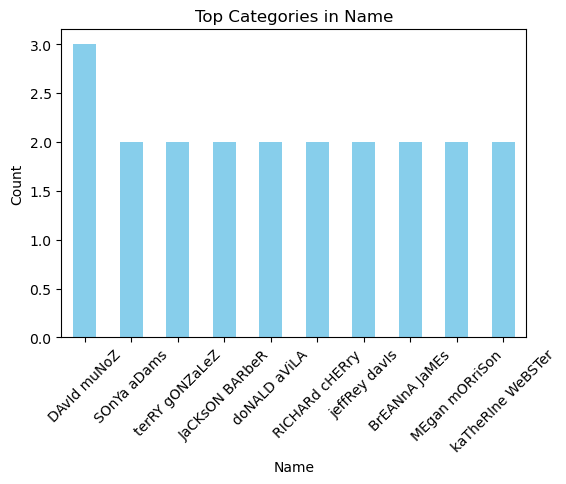

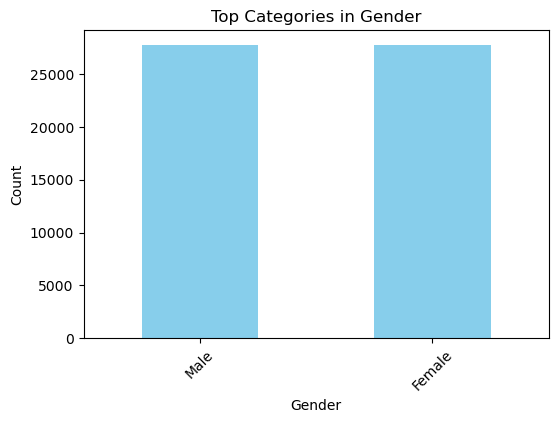

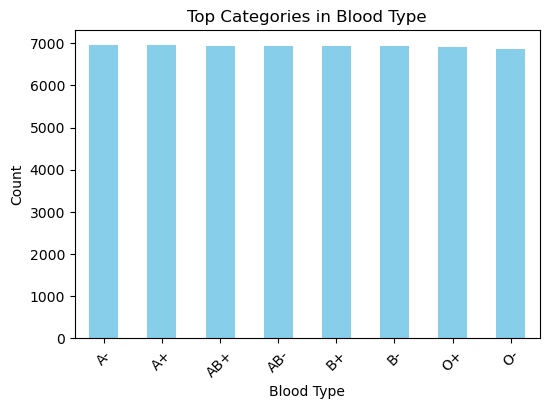

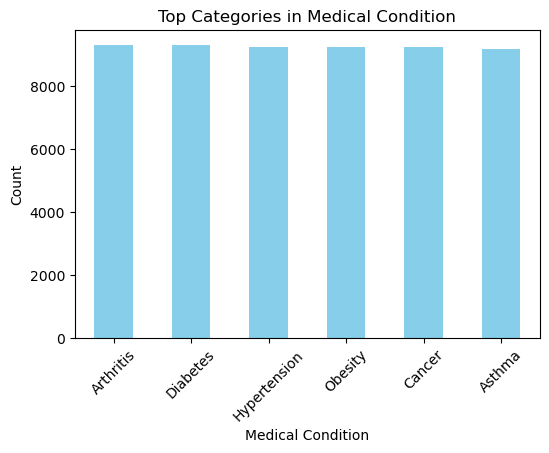

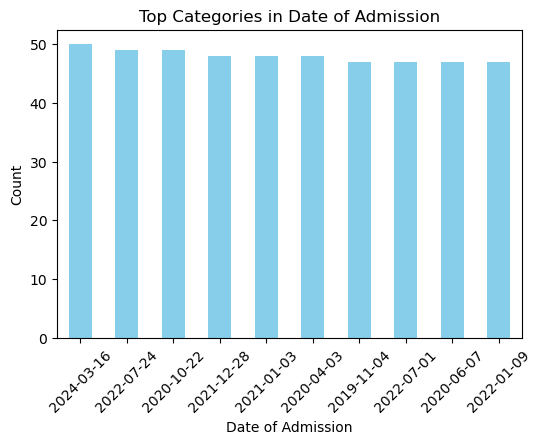

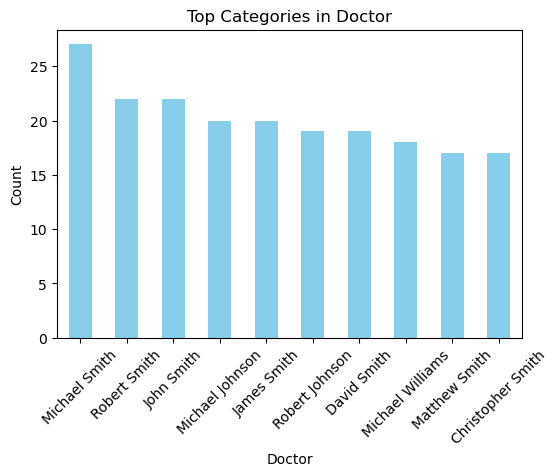

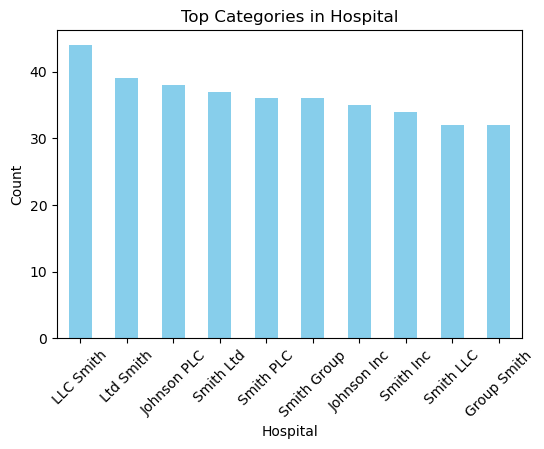

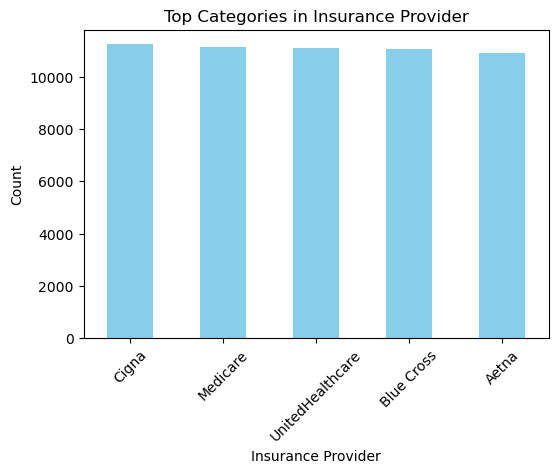

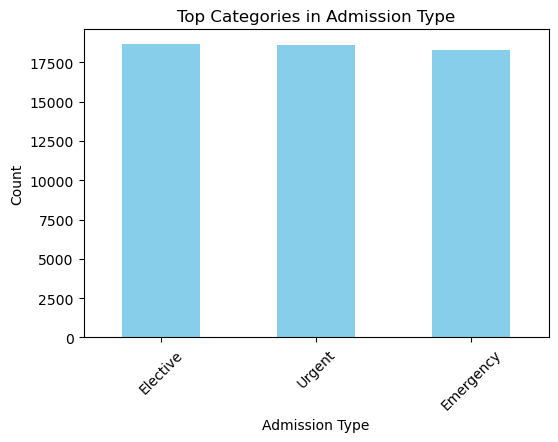

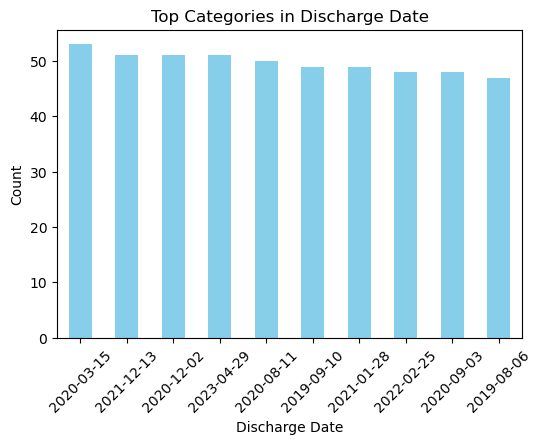

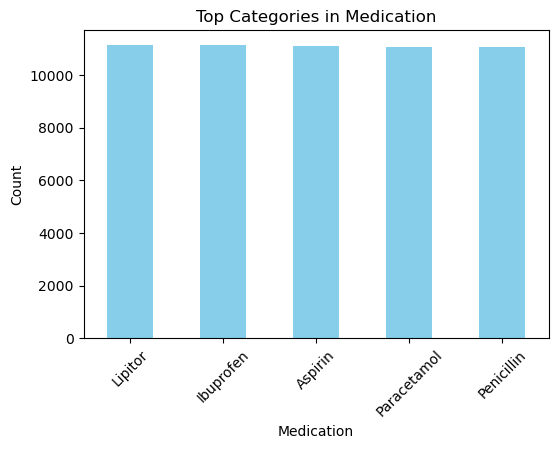

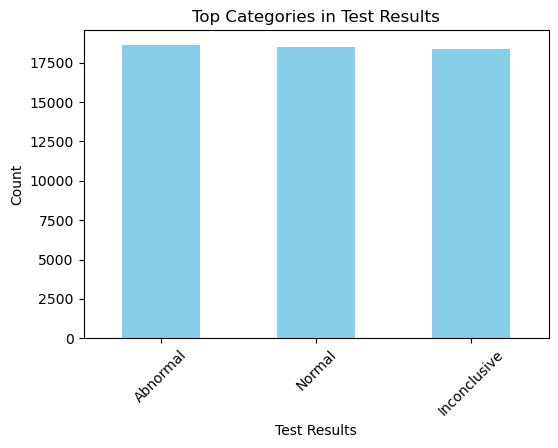

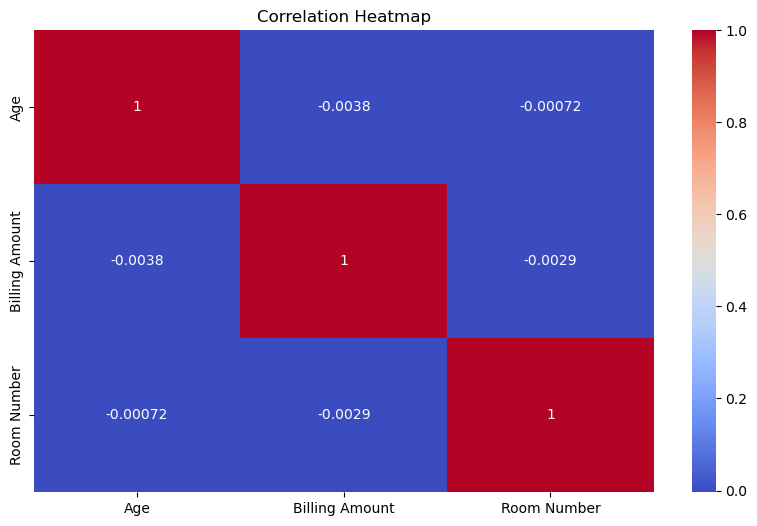


--- Outlier Detection via Boxplots ---


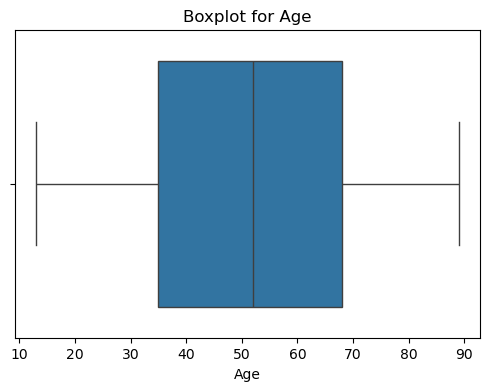

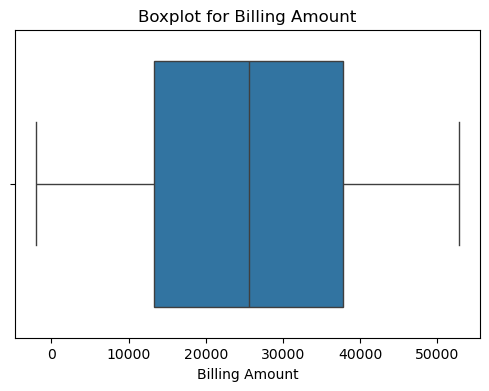

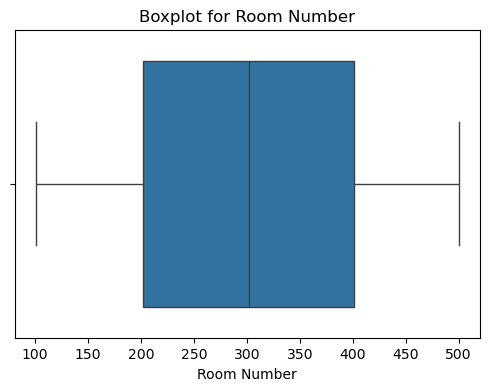


--- Quick Insights ---
Total Rows: 55500
Numeric Columns: 3 | Categorical Columns: 12
Missing Values Present: 0 columns
Duplicate Rows: 534
Data analysis completed successfully ✅


In [9]:
# --- 2. Load the Dataset ---
DATA_PATH = "healthcare_dataset.csv"

# Read CSV file
df = pd.read_csv(DATA_PATH)

# --- 3. Basic Overview ---
print("✅ Dataset Loaded Successfully!")
print("\n--- Shape of Dataset ---")
print(df.shape)

print("\n--- Column Names ---")
print(df.columns.tolist())

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- First 5 Rows ---")
display(df.head())

# --- 4. Missing Value Analysis ---
print("\n--- Missing Values ---")
print(df.isnull().sum())

# --- 5. Duplicate Records ---
duplicate_count = df.duplicated().sum()
print(f"\n--- Duplicate Rows Found: {duplicate_count} ---")

# --- 6. Basic Statistics ---
print("\n--- Summary Statistics ---")
display(df.describe(include='all').transpose())

# --- 7. Data Type Segregation ---
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print(f"\nNumeric Columns: {numeric_cols}")
print(f"Categorical Columns: {categorical_cols}")

# --- 8. Univariate Analysis (Numeric Columns) ---
print("\n--- Numeric Column Distributions ---")
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# --- 9. Univariate Analysis (Categorical Columns) ---
print("\n--- Categorical Column Counts ---")
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().head(10).plot(kind='bar', color='skyblue')
    plt.title(f"Top Categories in {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

# --- 10. Correlation Heatmap (for numeric features) ---
if len(numeric_cols) > 1:
    plt.figure(figsize=(10,6))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()
else:
    print("⚠️ Not enough numeric columns for correlation heatmap.")

# --- 11. Outlier Detection (Boxplots) ---
print("\n--- Outlier Detection via Boxplots ---")
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot for {col}")
    plt.show()

# --- 12. Basic Insights ---
print("\n--- Quick Insights ---")
print(f"Total Rows: {len(df)}")
print(f"Numeric Columns: {len(numeric_cols)} | Categorical Columns: {len(categorical_cols)}")
print(f"Missing Values Present: {df.isnull().any().sum()} columns")
print(f"Duplicate Rows: {duplicate_count}")
print("Data analysis completed successfully ✅")

✅ Dataset Loaded Successfully for Advanced Analytics

--- Cleaning Missing Values ---
Categorical columns encoded successfully.


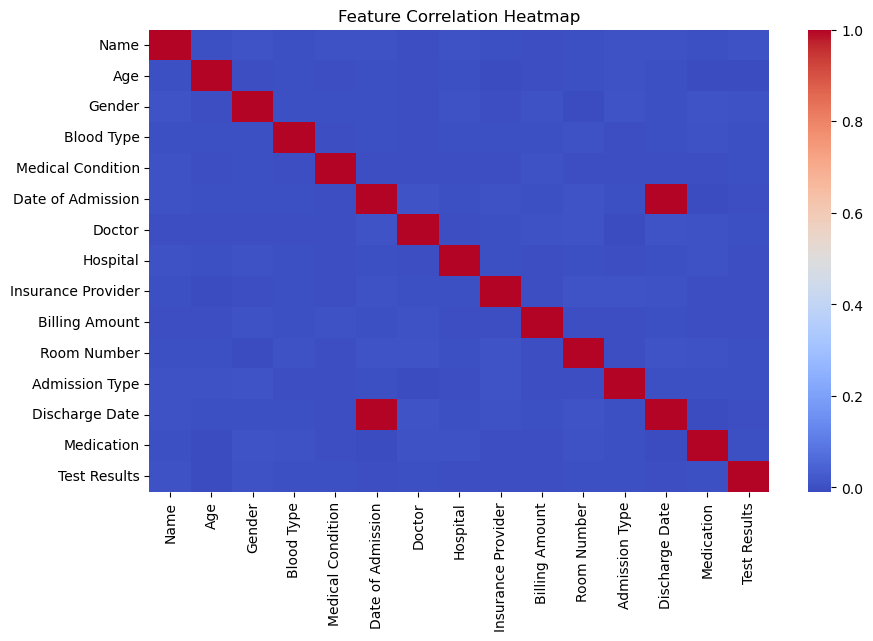


--- Principal Component Analysis ---


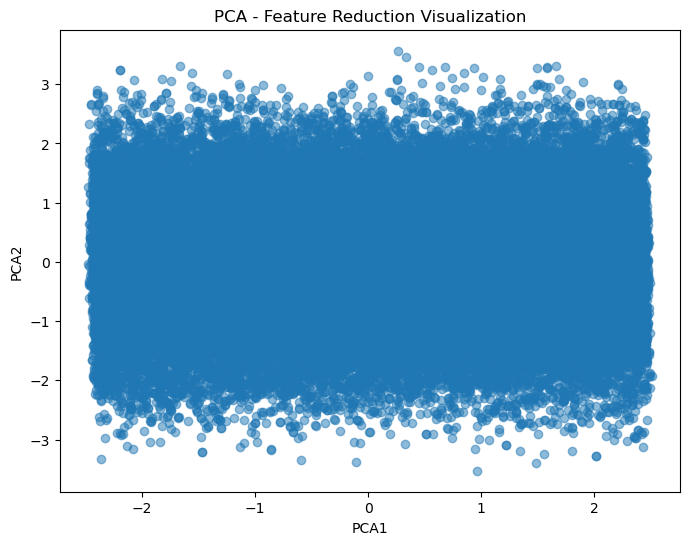

Explained Variance Ratio: [0.13335633 0.06835376]

--- KMeans Clustering ---


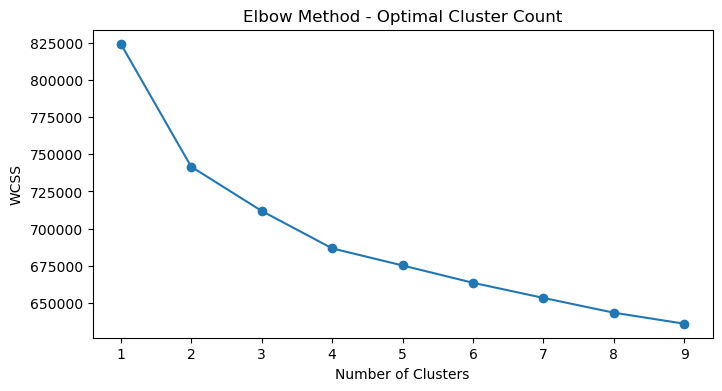

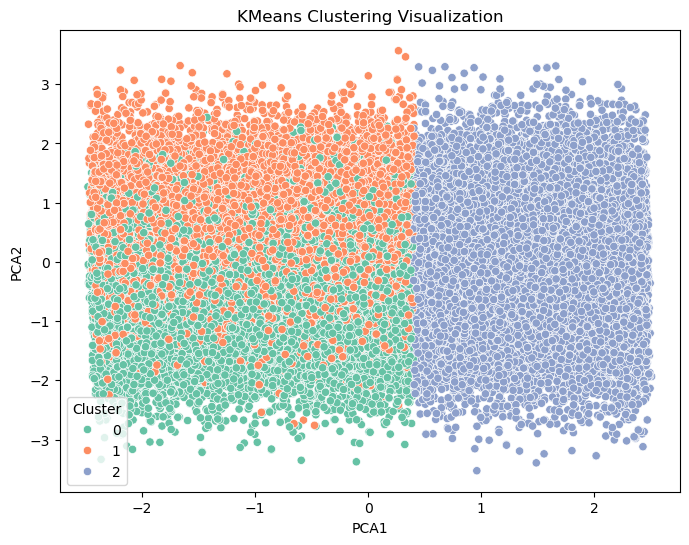


--- Feature Importance using Random Forest ---

Advanced analytics completed successfully ✅


In [11]:
# --- 2. Load Dataset ---
DATA_PATH = "healthcare_dataset.csv"
df = pd.read_csv(DATA_PATH)
print("✅ Dataset Loaded Successfully for Advanced Analytics")


# --- 3. Data Cleaning ---
print("\n--- Cleaning Missing Values ---")
df = df.drop_duplicates()
df = df.fillna(df.median(numeric_only=True))
df = df.fillna("Unknown")


# Encode categorical variables
df_encoded = df.copy()
label_encoders = {}
for col in df_encoded.select_dtypes(exclude=np.number).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le


print("Categorical columns encoded successfully.")


# --- 4. Correlation Heatmap ---
plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()


# --- 5. Principal Component Analysis (PCA) ---
print("\n--- Principal Component Analysis ---")
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)


pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)


df_pca = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
plt.figure(figsize=(8,6))
plt.scatter(df_pca['PCA1'], df_pca['PCA2'], alpha=0.5)
plt.title('PCA - Feature Reduction Visualization')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()


print("Explained Variance Ratio:", pca.explained_variance_ratio_)


# --- 6. Clustering (KMeans) ---
print("\n--- KMeans Clustering ---")


# Determine optimal clusters via Elbow Method
wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8,4))
plt.plot(range(1,10), wcss, marker='o')
plt.title('Elbow Method - Optimal Cluster Count')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


